# NGS variant calling workflow

<div style="background-color: PaleTurquoise; padding: 10px;">
    
This notebook contains a simple SNP calling workflow.

Please run and explore this workflow.

Areas with questions about QC are highlighted in yellow

</div>

## Case

Two exome sequencing samples of a T-Cell Acute Lymphoblastic Leukemia patient. 

One sample (`TLE66_T`) is of tumor, one healthy control sample  (`TLE66_N`)

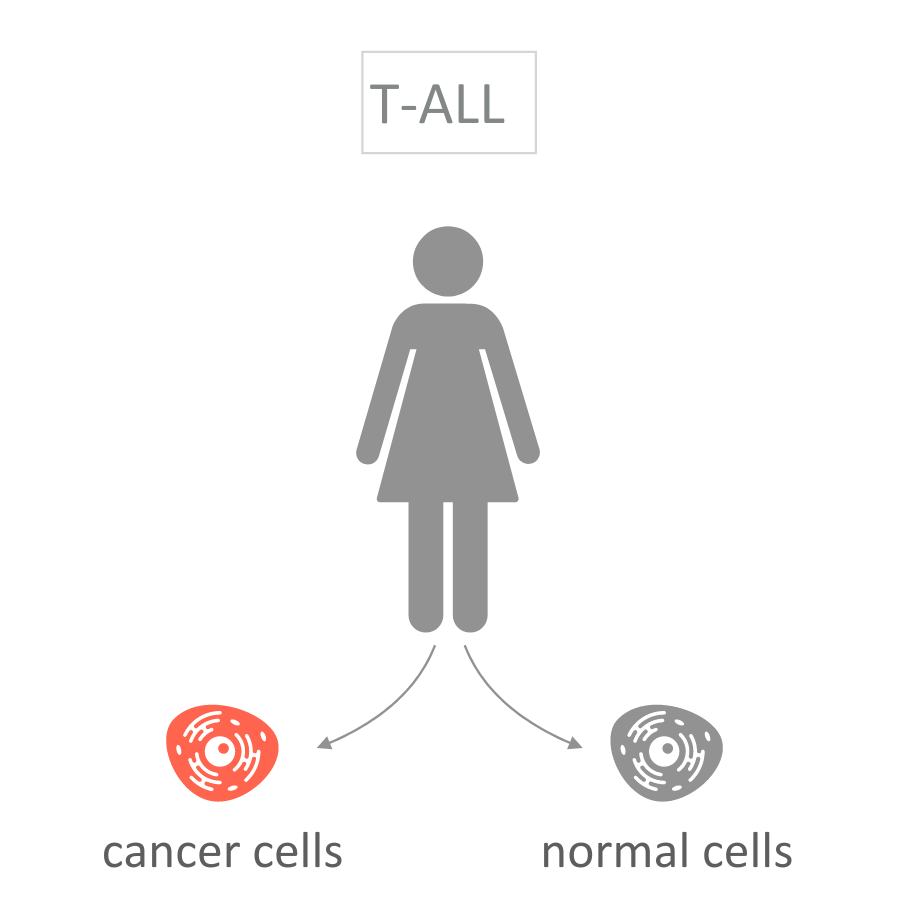

Goal: process the raw fastq, call & annotate SNPs.

We want to ultimately find interesting variants that may be causal to the T-ALL.

## Preparation

In [16]:
echo $VSC_DATA

/data/leuven/386/vsc38681


The cleanest way to work with notebooks is to first create a folder on your server (VSC). For example:

    mkdir $VSC_DATA/variant_calling_manual

- You can do this in the jupyter interface
- Upload your notebook to this folder
- Navigate to this folder from jupyter
- Open the notebook

This ensures you are always working from the correct location. If you did not do this, please shutdown this notebook and do this.

If you do not do this, you are in the wrong folder upon a notebook crash, or when you forget to cd into your workfolder.

In [17]:
# make sure we add our conda environment to the path
# there are also a number of command line tools installed
# You need to do this every time you need to use our conda env.

export PATH=/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/:$PATH

In [18]:
# ensure we are using the correct environment - test with bwa

which bwa

/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/bwa


In [19]:
# create a scratch folder! - Important to check you are working in the correct scratch folder for subsequent workœ
# Make sure you use absolute paths as much as possible - relative paths can give unexpected results.
# image running (`mkdir variant_calling_manual ; cd variant_calling_manual`) twice in a row.

mkdir -p $VSC_SCRATCH/variant_calling_manual
cd $VSC_SCRATCH/variant_calling_manual
pwd
ls

/scratch/leuven/386/vsc38681/variant_calling_manual
fastqc_output  TLE66_T.bam


In [20]:
# We will be using the genome sequence & index a few times - 
# So I'll use an environment variable

# Note - we are definitely using hg19 for this course.

# To keep memory requirements in check we're using a truncated database with just chromosome 9
DB=/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa

In [21]:
ls -lh $DB

-rw-rw-r--+ 1 vsc30690 lp_edu_large_omics 135M Jan 24  2014 /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


In [29]:
cd /data/leuven/386/vsc38681/variant_calling_manual
pwd
ls -lh

/data/leuven/386/vsc38681/variant_calling_manual
total 70M
-rw-r----- 1 vsc38681 vsc38681    0 Mar  3 22:59 '=AECFBHGBEEEECCHEEFEFFDFCDIHKGEI'
-rw-r----- 1 vsc38681 vsc38681 1.7M Mar  4 16:11  annotated_snps.vcf
-rw-r----- 1 vsc38681 vsc38681    0 Mar  3 22:59 'B:CCAFFDDCEC=JGFIEC?5'
-rw-r----- 1 vsc38681 vsc38681  211 Mar  1 22:08  candidate_somatic_clean.tsv
-rw-r----- 1 vsc38681 vsc38681  211 Mar  1 22:02  candidate_somatic.tsv
-rw-r----- 1 vsc38681 vsc38681    0 Mar  3 22:59  CKGCKGIFFGBG
-rw-r----- 1 vsc38681 vsc38681    0 Mar  4 21:11  clean_snps.vcf
-rw-r----- 1 vsc38681 vsc38681    0 Mar  1 22:04  clean_snps.vcfctrue
drwxr-x--- 2 vsc38681 vsc38681 4.0K Mar  1 20:57  fastqc_output
drwxr-x--- 2 vsc38681 vsc38681 4.0K Mar  1 22:18  final_results
-rw-r----- 1 vsc38681 vsc38681 407K Mar  4 21:12  manual_snp_calling_workflow.ipynb
-rw-r----- 1 vsc38681 vsc38681 960K Mar  4 15:35  raw_snps.vcf
-rw-r----- 1 vsc38681 vsc38681  43K Mar  4 16:11  snpEff_genes.txt
-rw-r----- 1 vsc38681 vsc

<div style="background-color: khaki; padding: 10px;">

## Prepare

* What are the version numbers of all tools used in this notebook. Get it from the tools!
 
</div>

In [22]:
module load FastQC
fastqc --version

FastQC v0.12.1


In [23]:
bwa 2>&1 | grep Version

Version: 0.7.19-r1273


In [24]:
samtools --version 2>&1 | head -n 1

samtools 1.23


In [25]:
bcftools --version 2>&1 | head -n 1

bcftools 1.23


In [26]:
java -jar $SNPEFF_JAR -version 2>&1 | head -n 1

openjdk version "25.0.1-internal" 2025-10-21


In [27]:
# Create a symlink to VSC_SCRATCH from $VSC_DATA -
# so that you can inspect your data using the jupyter file browser
ln -sf $VSC_SCRATCH $VSC_DATA/scratch 

In [14]:
ln -sf /staging/leuven/stg_00079/teaching/data_manual_snpcall/*.fastq .
ls -l

total 71008
-rw-r----- 1 vsc38681 vsc38681        0 Mar  3 22:59 '=AECFBHGBEEEECCHEEFEFFDFCDIHKGEI'
-rw-r----- 1 vsc38681 vsc38681  1775439 Mar  4 16:11  annotated_snps.vcf
-rw-r----- 1 vsc38681 vsc38681        0 Mar  3 22:59 'B:CCAFFDDCEC=JGFIEC?5'
-rw-r----- 1 vsc38681 vsc38681      211 Mar  1 22:08  candidate_somatic_clean.tsv
-rw-r----- 1 vsc38681 vsc38681      211 Mar  1 22:02  candidate_somatic.tsv
-rw-r----- 1 vsc38681 vsc38681        0 Mar  3 22:59  CKGCKGIFFGBG
-rw-r----- 1 vsc38681 vsc38681        0 Mar  4 21:11  clean_snps.vcf
-rw-r----- 1 vsc38681 vsc38681        0 Mar  1 22:04  clean_snps.vcfctrue
drwxr-x--- 2 vsc38681 vsc38681     4096 Mar  1 20:57  fastqc_output
drwxr-x--- 2 vsc38681 vsc38681     4096 Mar  1 22:18  final_results
-rw-r----- 1 vsc38681 vsc38681   416527 Mar  4 21:12  manual_snp_calling_workflow.ipynb
-rw-r----- 1 vsc38681 vsc38681   982232 Mar  4 15:35  raw_snps.vcf
-rw-r----- 1 vsc38681 vsc38681    43281 Mar  4 16:11  snpEff_genes.txt
-rw-r----- 1 vsc3868

The `sha256` checksums of these files are supposed to be:

    5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9  TLE66_N.fastq
    cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe  TLE66_T.fastq


<div style="background-color: khaki; padding: 10px;">

## Raw data Quality Control

* Do the checksums match?
* Do the raw files look like fastq?
* Do they have a reasonable number of reads?
 
</div>

1. Yes. The computed SHA256 checksums for both FASTQ files exactly match the expected values for both TLE66_N.fastq and TLE66_T.fastq
2. The files follow the standard FASTQ 4-line structure, header starting with "@", sequence line, "+" separator, and quality scores. Therefore, the raw files are valid FASTQ format.
3. Yes, The total number of reads was calculated by dividing the total number of lines by four: TLE66_N.fastq: 540624 reads, TLE66_T.fastq: 477888 reads. These read counts are reasonable for sequencing data and suitable for downstream analysis

In [30]:
# you can get help using
fastqc --help


            FastQC - A high throughput sequence QC analysis tool

SYNOPSIS

	fastqc seqfile1 seqfile2 .. seqfileN

    fastqc [-o output dir] [--(no)extract] [-f fastq|bam|sam] 
           [-c contaminant file] seqfile1 .. seqfileN

DESCRIPTION

    FastQC reads a set of sequence files and produces from each one a quality
    control report consisting of a number of different modules, each one of 
    which will help to identify a different potential type of problem in your
    data.
    
    If no files to process are specified on the command line then the program
    will start as an interactive graphical application.  If files are provided
    on the command line then the program will run with no user interaction
    required.  In this mode it is suitable for inclusion into a standardised
    analysis pipeline.
    
    The options for the program as as follows:
    
    -h --help       Print this help file and exit
    
    -v --version    Print the version of the program and exit

In [31]:
# Run fastqc - could take a minute or two
mkdir -p fastqc_output
fastqc *.fastq -o fastqc_output

null
null
Started analysis of TLE66_N.fastq
Approx 5% complete for TLE66_N.fastq
Approx 10% complete for TLE66_N.fastq
Approx 15% complete for TLE66_N.fastq
Approx 20% complete for TLE66_N.fastq
Approx 25% complete for TLE66_N.fastq
Approx 30% complete for TLE66_N.fastq
Approx 35% complete for TLE66_N.fastq
Approx 40% complete for TLE66_N.fastq
Approx 45% complete for TLE66_N.fastq
Approx 50% complete for TLE66_N.fastq
Approx 55% complete for TLE66_N.fastq
Approx 60% complete for TLE66_N.fastq
Approx 65% complete for TLE66_N.fastq
Approx 70% complete for TLE66_N.fastq
Approx 75% complete for TLE66_N.fastq
Approx 80% complete for TLE66_N.fastq
Approx 85% complete for TLE66_N.fastq
Approx 90% complete for TLE66_N.fastq
Approx 95% complete for TLE66_N.fastq
Analysis complete for TLE66_N.fastq
Started analysis of TLE66_T.fastq
Approx 5% complete for TLE66_T.fastq
Approx 10% complete for TLE66_T.fastq
Approx 15% complete for TLE66_T.fastq
Approx 20% complete for TLE66_T.fastq
Approx 25% com

Back in your jupyter browser you can see the html & zip outputs

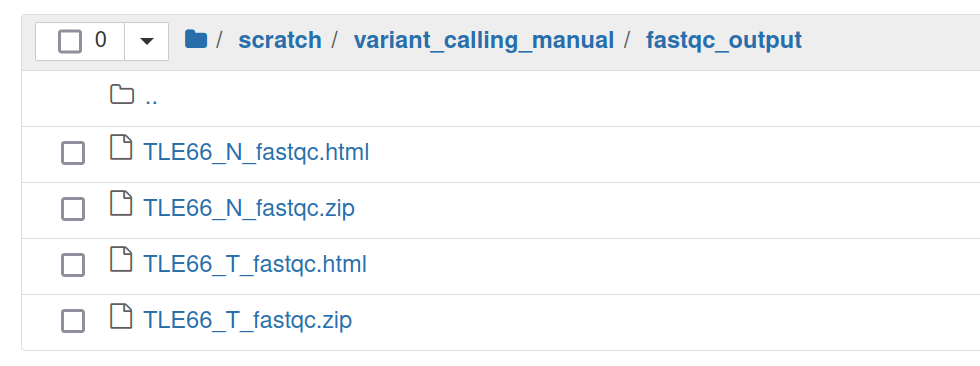


<div style="background-color: khaki; padding: 10px;">

## Fastq data Quality Control

* Is the quality ok?
* How is the quality score encoded? Do you need to take this into account?
 
</div>

1. Yes, overall read quality is good: per-base quality scores are high and no adapter/overrepresented sequence problems are detected. 
The only warning is GC-content distribution, which is expected for targeted/biased data and is not a major concern here
2. From my FastQC Basic Statistics table, the encoding is Sanger / Illumina 1.9, which corresponds to Phred+33 encoding. 
I dont need to take this into account because this is the standard encoding used by modern Illumina sequencing platforms. 
No additional conversion is required, as downstream tools assume Phred+33 by default

## Align the reads

We will be using `bwa mem`. Get help by running without arguments

In [32]:
bwa mem || true


Usage: bwa mem [options] <idxbase> <in1.fq> [in2.fq]

Algorithm options:

       -t INT        number of threads [1]
       -k INT        minimum seed length [19]
       -w INT        band width for banded alignment [100]
       -d INT        off-diagonal X-dropoff [100]
       -r FLOAT      look for internal seeds inside a seed longer than {-k} * FLOAT [1.5]
       -y INT        seed occurrence for the 3rd round seeding [20]
       -c INT        skip seeds with more than INT occurrences [500]
       -D FLOAT      drop chains shorter than FLOAT fraction of the longest overlapping chain [0.50]
       -W INT        discard a chain if seeded bases shorter than INT [0]
       -m INT        perform at most INT rounds of mate rescues for each read [50]
       -S            skip mate rescue
       -P            skip pairing; mate rescue performed unless -S also in use

Scoring options:

       -A INT        score for a sequence match, which scales options -TdBOELU unless overridden [1]
     

In [33]:
echo ${DB}

/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


In [34]:
bwa mem ${DB} TLE66_N.fastq | samtools sort -o TLE66_N.bam -

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.004 CPU sec, 2.959 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.398 CPU sec, 3.325 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.415 CPU sec, 3.346 real sec
[M::process] read 7288 sequences (546600 bp)...
[M::mem_process_seqs] Processed 133334 reads in 4.253 CPU sec, 4.227 real sec
[M::mem_process_seqs] Processed 7288 reads in 0.286 CPU sec, 0.252 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
[main] Real time: 15.716 sec; CPU: 14.553 sec


In [35]:
bwa mem ${DB} TLE66_T.fastq | samtools sort - > TLE66_T.bam

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.068 CPU sec, 3.025 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.420 CPU sec, 3.351 real sec
[M::process] read 77886 sequences (5841450 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.535 CPU sec, 3.483 real sec
[M::mem_process_seqs] Processed 77886 reads in 2.814 CPU sec, 2.786 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_T.fastq
[main] Real time: 12.803 sec; CPU: 12.984 sec


In [38]:
# create indici
samtools index TLE66_N.bam
samtools index TLE66_T.bam

In [39]:
pwd
ls -l

/data/leuven/386/vsc38681/variant_calling_manual
total 71012
-rw-r----- 1 vsc38681 vsc38681        0 Mar  3 22:59 '=AECFBHGBEEEECCHEEFEFFDFCDIHKGEI'
-rw-r----- 1 vsc38681 vsc38681  1775439 Mar  4 16:11  annotated_snps.vcf
-rw-r----- 1 vsc38681 vsc38681        0 Mar  3 22:59 'B:CCAFFDDCEC=JGFIEC?5'
-rw-r----- 1 vsc38681 vsc38681      211 Mar  1 22:08  candidate_somatic_clean.tsv
-rw-r----- 1 vsc38681 vsc38681      211 Mar  1 22:02  candidate_somatic.tsv
-rw-r----- 1 vsc38681 vsc38681        0 Mar  3 22:59  CKGCKGIFFGBG
-rw-r----- 1 vsc38681 vsc38681        0 Mar  4 21:11  clean_snps.vcf
-rw-r----- 1 vsc38681 vsc38681        0 Mar  1 22:04  clean_snps.vcfctrue
drwxr-x--- 2 vsc38681 vsc38681     4096 Mar  1 20:57  fastqc_output
drwxr-x--- 2 vsc38681 vsc38681     4096 Mar  1 22:18  final_results
-rw-r----- 1 vsc38681 vsc38681   421598 Mar  4 21:14  manual_snp_calling_workflow.ipynb
-rw-r----- 1 vsc38681 vsc38681   982232 Mar  4 15:35  raw_snps.vcf
-rw-r----- 1 vsc38681 vsc38681    43281 Ma

<div style="background-color: khaki; padding: 10px;">

## BAM  Quality control

* Did all tools finish without error?
* Is the header correct? (Use `samtools view -H`)
* Do the files look like BAM? (Use `samtools view ... | head`)
* To which chromosomes to the reads map? (Use `samtools idxstats`) What do you expect? 
* How many & what percentage of the reads map properly? (Use `samtools flagstat`)
* Download the bam & bai files to disk & visualize in [IGV](https://igv.org/app/). Copy/paste a screenshot.

</div>

1. Yes. The BAM files were created and are non-empty, with TLE66_N.bam = 35M and TLE66_T.bam = 31M
Also, samtools view, idxstats, and flagstat all ran successfully, which strongly indicates the BAMs are valid and indexing worked
2. Yes. The header contains:
@HD VN:1.5 SO:coordinate, which means sorted BAM
@SQ SN:chr9 LN:138394717, which means reference is chr9 only, length matches the chr9 reference
@PG entries show the programs used: bwa mem (BWA 0.7.19-r1273) and samtools sort (samtools 1.23)
This is consistent with the workflow and reference genome used
3. Yes. samtools view TLE66_N.bam | head prints normal SAM alignment records: read name, FLAG, reference name (chr9), position, MAPQ, CIGAR, sequence + quality, tags (e.g., NM, MD, AS)
So the BAM content structure is correct.
4. From idxstats:
- Normal (TLE66_N): chr9 mapped: 540,563 and unmapped (*): 98
- Tumor (TLE66_T): chr9 mapped: 477,793 and unmapped (*): 125
My xpectation is that reads should map to chr9 only, because the reference used was the truncated database containing only chr9, which matches exactly.
5. From flagstat:
- TLE66_N.bam: total reads: 540,661 and mapped: 540,563 (99.98%)
- TLE66_T.bam: mapped: 477,793 (99.97%)
Flagstat reports 0 paired in sequencing, meaning these FASTQs were treated as single-end (one FASTQ per sample), so “properly paired” is not applicable (N/A) here. That’s expected.
Overall mapping rate is extremely high (~99.97–99.98%), indicating successful alignment.

## SNP Calling

Using bcftools

In [40]:
#get help
bcftools mpileup || true


Usage: bcftools mpileup [options] in1.bam [in2.bam [...]]

Input options:
  -6, --illumina1.3+      Quality is in the Illumina-1.3+ encoding
  -A, --count-orphans     Include anomalous read pairs, with flag PAIRED but not PROPER_PAIR set
  -b, --bam-list FILE     List of input BAM filenames, one per line
  -B, --no-BAQ            Disable BAQ (per-Base Alignment Quality)
  -C, --adjust-MQ INT     Adjust mapping quality [0]
  -D, --full-BAQ          Apply BAQ everywhere, not just in problematic regions
  -d, --max-depth INT     Max raw per-file depth; avoids excessive memory usage [250]
  -E, --redo-BAQ          Recalculate BAQ on the fly, ignore existing BQs
  -f, --fasta-ref FILE    Faidx indexed reference sequence file
      --no-reference      Do not require fasta reference file
  -G, --read-groups FILE  Select or exclude read groups listed in the file
  -q, --min-MQ INT        Skip alignments with mapQ smaller than INT [0]
  -Q, --min-BQ INT        Skip bases with baseQ/BAQ smaller

In [41]:
cd /data/leuven/386/vsc38681/variant_calling_manual
pwd
ls -lh

/data/leuven/386/vsc38681/variant_calling_manual
total 70M
-rw-r----- 1 vsc38681 vsc38681    0 Mar  3 22:59 '=AECFBHGBEEEECCHEEFEFFDFCDIHKGEI'
-rw-r----- 1 vsc38681 vsc38681 1.7M Mar  4 16:11  annotated_snps.vcf
-rw-r----- 1 vsc38681 vsc38681    0 Mar  3 22:59 'B:CCAFFDDCEC=JGFIEC?5'
-rw-r----- 1 vsc38681 vsc38681  211 Mar  1 22:08  candidate_somatic_clean.tsv
-rw-r----- 1 vsc38681 vsc38681  211 Mar  1 22:02  candidate_somatic.tsv
-rw-r----- 1 vsc38681 vsc38681    0 Mar  3 22:59  CKGCKGIFFGBG
-rw-r----- 1 vsc38681 vsc38681    0 Mar  4 21:11  clean_snps.vcf
-rw-r----- 1 vsc38681 vsc38681    0 Mar  1 22:04  clean_snps.vcfctrue
drwxr-x--- 2 vsc38681 vsc38681 4.0K Mar  1 20:57  fastqc_output
drwxr-x--- 2 vsc38681 vsc38681 4.0K Mar  1 22:18  final_results
-rw-r----- 1 vsc38681 vsc38681 437K Mar  4 21:16  manual_snp_calling_workflow.ipynb
-rw-r----- 1 vsc38681 vsc38681 960K Mar  4 15:35  raw_snps.vcf
-rw-r----- 1 vsc38681 vsc38681  43K Mar  4 16:11  snpEff_genes.txt
-rw-r----- 1 vsc38681 vsc

In [42]:
ln -sf /staging/leuven/stg_00079/teaching/data_manual_snpcall/*.fastq .
ls -lh *.fastq

lrwxrwxrwx 1 vsc38681 vsc38681 68 Mar  4 21:16 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
lrwxrwxrwx 1 vsc38681 vsc38681 68 Mar  4 21:16 TLE66_T.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_T.fastq


In [43]:
bcftools mpileup -Ou -f ${DB} TLE66_N.bam TLE66_T.bam \
    | bcftools call -mv -Ov -o raw_snps.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 2 samples in 2 input files
[mpileup] maximum number of reads per input file set to -d 250


In [46]:
ls

'=AECFBHGBEEEECCHEEFEFFDFCDIHKGEI'   manual_snp_calling_workflow.ipynb
 annotated_snps.vcf		     raw_snps.vcf
'B:CCAFFDDCEC=JGFIEC?5'		     snpEff_genes.txt
 candidate_somatic_clean.tsv	     snpEff_summary.html
 candidate_somatic.tsv		     TLE66_N.bam
 CKGCKGIFFGBG			     TLE66_N.bam.bai
 clean_snps.vcf			     TLE66_N.fastq
 clean_snps.vcfctrue		     TLE66_T.bam
 fastqc_output			     TLE66_T.bam.bai
 final_results			     TLE66_T.fastq


In [45]:
head raw_snps.vcf

##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">


In [47]:
grep  '^#' raw_snps.vcf | tail

##FORMAT=<ID=PL,Number=G,Type=Integer,Description="List of Phred-scaled genotype likelihoods">
##FORMAT=<ID=AD,Number=R,Type=Integer,Description="Allelic depths (high-quality bases)">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Allele count in genotypes for each ALT allele, in the same order as listed">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=DP4,Number=4,Type=Integer,Description="Number of high-quality ref-forward , ref-reverse, alt-forward and alt-reverse bases">
##INFO=<ID=MQ,Number=1,Type=Integer,Description="Average mapping quality">
##bcftools_callVersion=1.23+htslib-1.23
##bcftools_callCommand=call -mv -Ov -o raw_snps.vcf; Date=Wed Mar  4 21:16:49 2026
#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	TLE66_N.bam	TLE66_T.bam


In [48]:
grep -v '^#' raw_snps.vcf | head -5

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082813	.	C	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082814	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	35641185	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./.:0,0,0:0,0


In [49]:
grep -v '^#' raw_snps.vcf | awk '$10!=$11' | head

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082813	.	C	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082814	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	35641185	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./.:0,0,0:0,0
chr9	35641189	.	G	A	7.01214	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:33,3,0:0,1	./.:0,0,0:0,0
chr9	35641192	.	G	T	7.83031	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:34,3,0:0,1	./.:0,0,0:0,0
chr9	35641215	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./

<div style="background-color: khaki; padding: 10px;">

## VCF/bcftools Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>

In [50]:
grep -v '#' raw_snps.vcf | head -2

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2


In [51]:
grep -v '^#' raw_snps.vcf | awk '$10!=$11' | head

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082813	.	C	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082814	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	35641185	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./.:0,0,0:0,0
chr9	35641189	.	G	A	7.01214	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:33,3,0:0,1	./.:0,0,0:0,0
chr9	35641192	.	G	T	7.83031	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:34,3,0:0,1	./.:0,0,0:0,0
chr9	35641215	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./

1. Yes, all tools finished successfully.
The raw_snps.vcf file was generated and has a reasonable file size (~960K), which shows that bcftools completed the variant calling step. 
The VCF header includes the bcftools version (1.23), and no error messages were produced after fixing the reference indexing issue. 
Therefore, the variant calling step ran without problems.
2. Yes, the VCF structure looks correct.
The file contains
- 28 meta-information lines starting with ##
- Exactly 1 header line starting with #CHROM
- 6661 variant lines
All variants are located on chr9, which is expected because the alignment was done against a reference containing only chromosome 9. 
The format follows VCFv4.2 and appears valid.
3. One example of a high-quality SNP is:
- chr9 128222151 C>A
- QUAL = 486.059
- DP = 354
- MQ = 60
- Genotype = 1/1 in both samples
I considered this SNP high quality because:
- The QUAL score is very high (~486), meaning strong confidence in the variant call.
- The depth (DP=354) is high, so many reads support the position.
- The mapping quality (MQ=60) indicates the reads are well aligned.
- The allele depth (AD) shows strong support for the alternate allele.
Overall, this SNP appears technically very reliable.
4. To find variants that differ between the two samples, I compared the genotype columns in the VCF file using the following command: grep -v '^#' raw_snps.vcf | awk '$10!=$11'
This prints variants where the genotype of the two samples is different. One example of such a variant is: chr9 34082802 C>T
At this position, the tumor sample has genotype 1/1, meaning the variant allele is present, while the normal sample has ./., meaning no variant was detected. This suggests that the mutation is present in the tumor sample but not in the normal sample, which could indicate a potential somatic mutation.
5. The SNP at chr9:34082802 was visualized in IGV using the aligned BAM files for both samples.
In IGV, the tumor sample shows reads supporting the T allele, while the normal sample shows reads matching the reference C allele. This confirms that the variant is present in the tumor sample but not in the normal sample.
A screenshot of the IGV view for this position is included below.

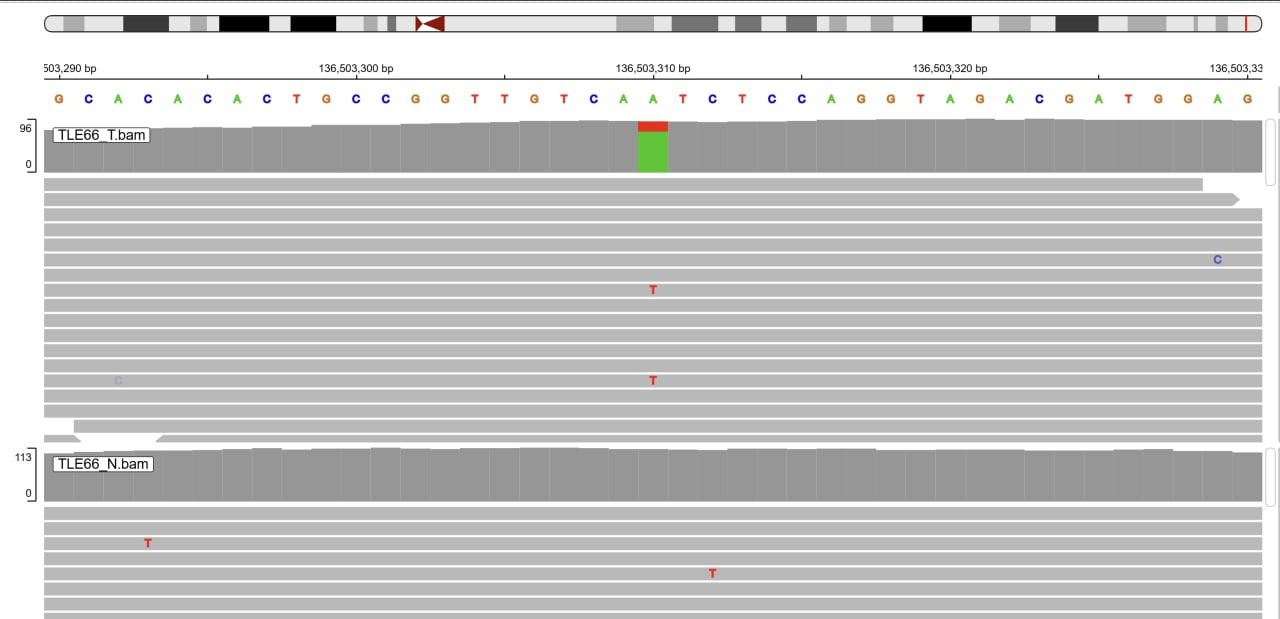






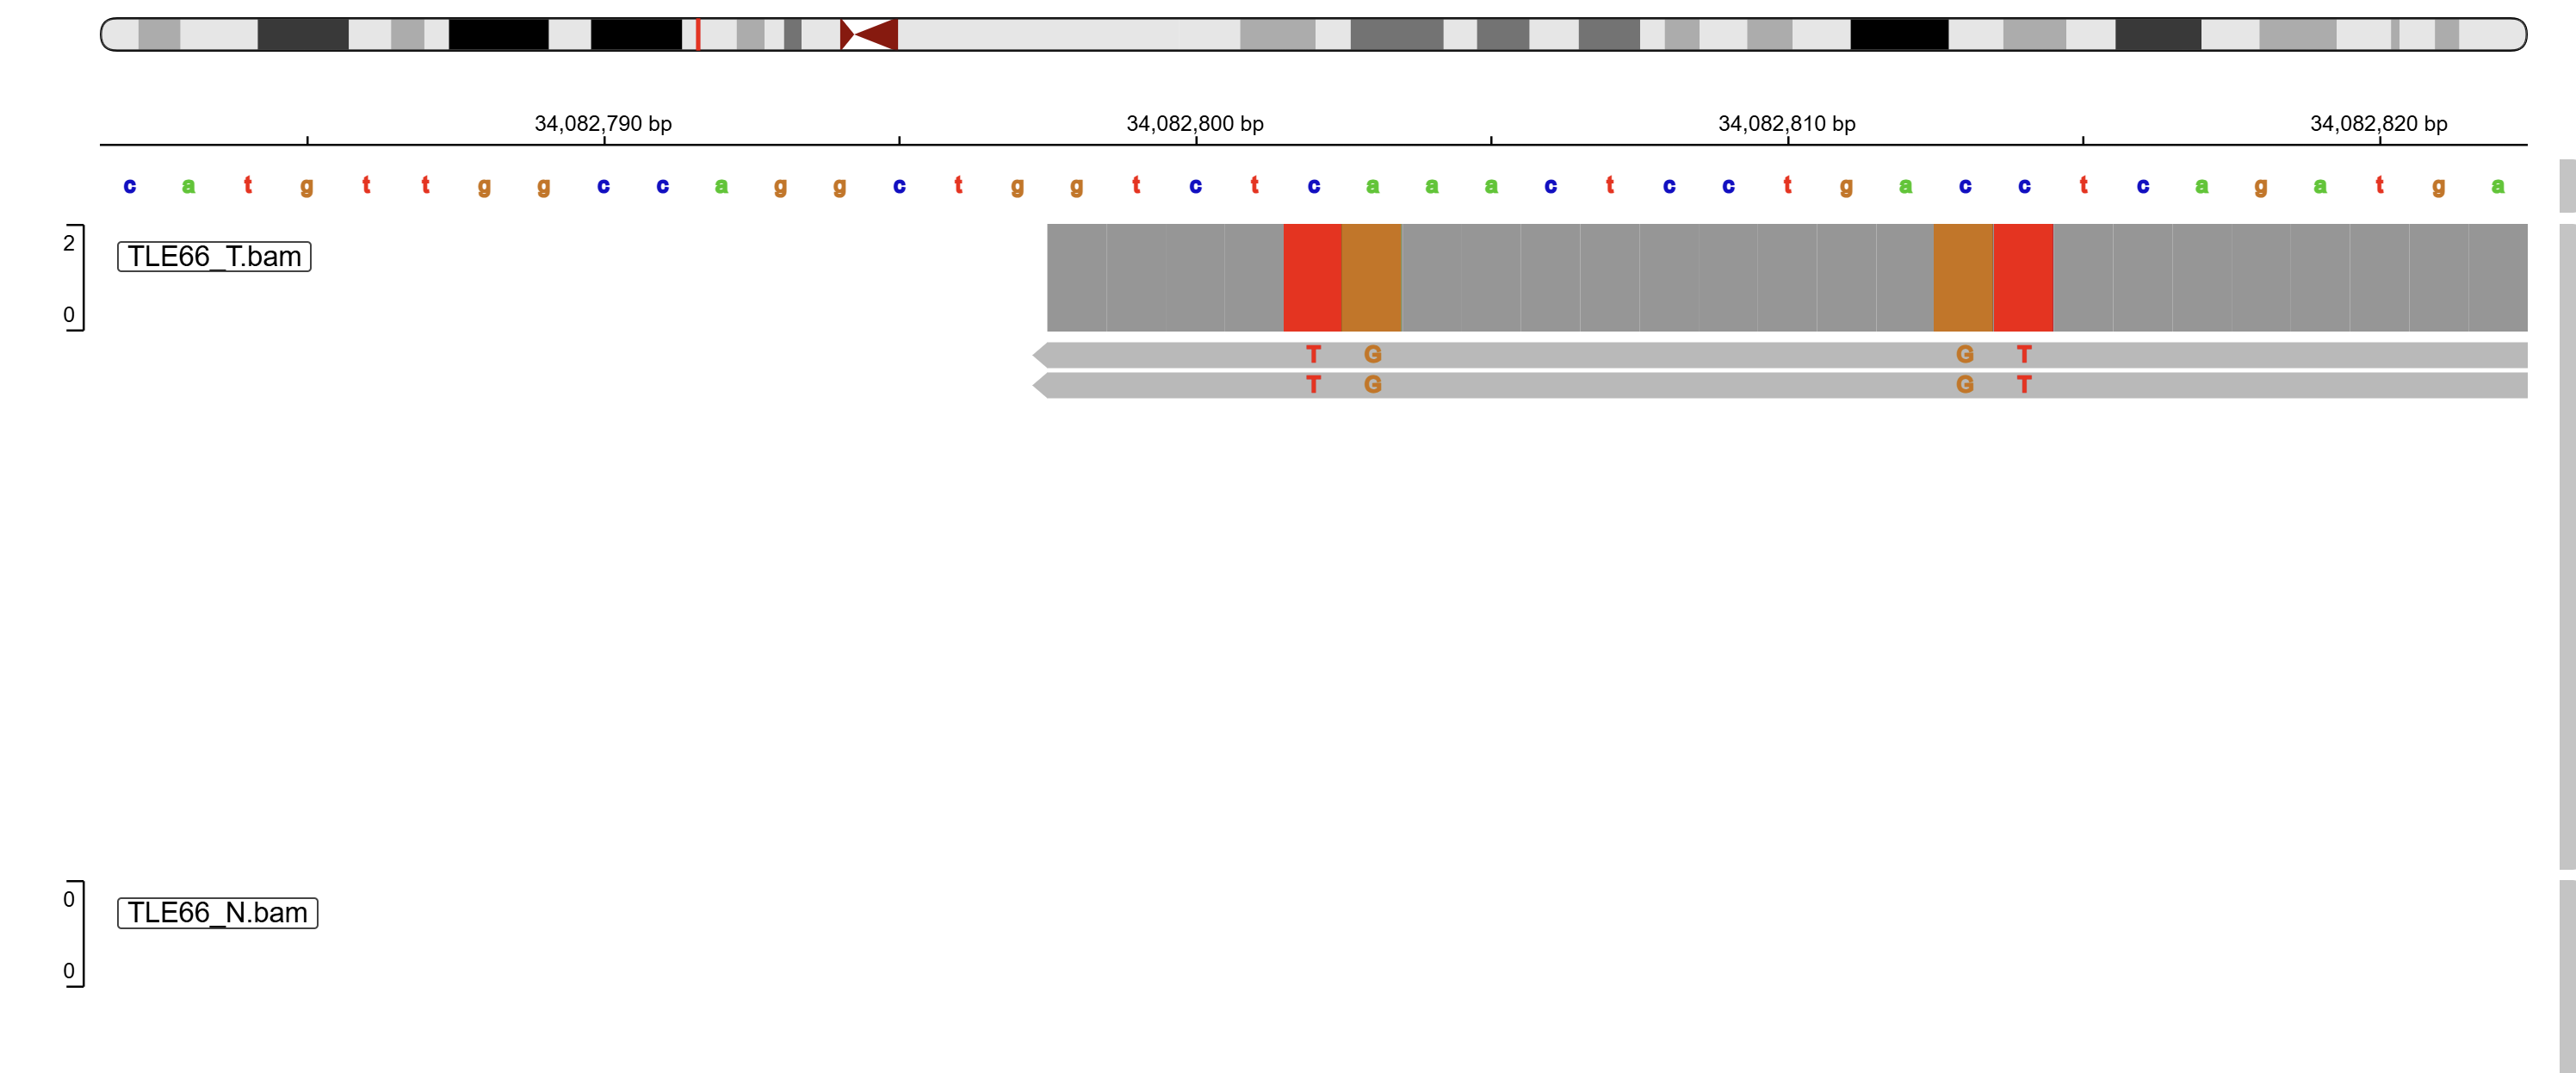

Not all SNPs are equaly convincing

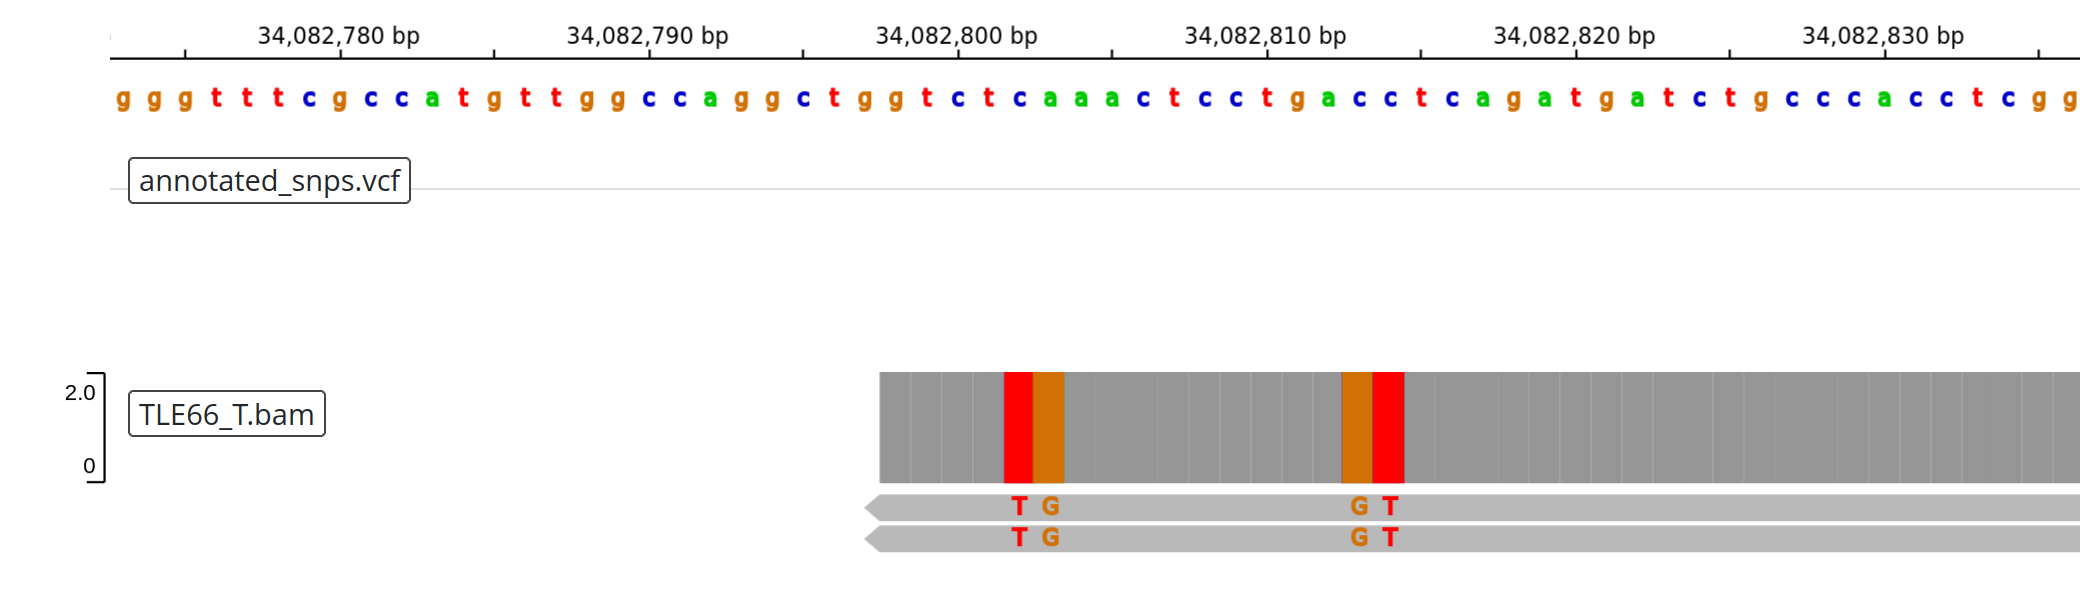

## SNP filtering & cleaning using `vt`

This is a VCF preprocessing pipeline that cleans up raw SNP calls before any downstream analysis. Each step fixes a specific class of problem:

* `vt decompose` splits multi-allelic variants (where multiple alternate alleles are listed on a single line) into separate biallelic records. Most tools downstream expect one variant per line, and PRS methods in particular are built around biallelic SNPs.
* `vt normalize -n -r $DB` left-aligns and normalizes indels against the reference genome. The same variant can be represented in multiple valid ways in VCF format — normalization ensures you have one canonical representation, which is critical when matching variants across datasets (e.g., GWAS summary statistics vs. your genotype calls).
* `vt uniq` removes exact duplicate records that may have arisen after decomposition and normalization — two originally different representations that are now identical.
* `vt view -f "QUAL>20"` filters out low-confidence variant calls. QUAL<20 corresponds roughly to less than 99% confidence that the variant is real, so you're dropping the noisiest calls.


In [52]:
cat raw_snps.vcf \
    | vt decompose - \
    | vt normalize -n -r $DB - \
    | vt uniq - \
    | vt view -f "QUAL>20" -h - \
    > clean_snps.vcf

uniq v0.57

options:     input VCF file        -
         [o] output VCF file       -
decompose v0.5

options:     input VCF file        -
         [s] smart decomposition   false (experimental)
         [o] output VCF file       -

normalize v0.5

options:     input VCF file                                  -
         [o] output VCF file                                 -
         [w] sorting window size                             10000
         [n] no fail on reference inconsistency for non SNPs true
         [q] quiet                                           false
         [d] debug                                           false
         [r] reference FASTA file                            /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


stats: no. variants                 : 6661
       no. biallelic variants       : 6659
       no. multiallelic variants    : 2

       no. additional biallelics    : 2
       total no. of biallelics      : 6663

Time elapsed: 0.02s


stats: biall


<div style="background-color: khaki; padding: 10px;">

## Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>



1. Yes, all tools finished successfully without errors.
The commands using vt decompose, vt normalize, vt uniq, and vt view all completed and produced output statistics without any error messages. The pipeline also produced the final file clean_snps.vcf, which indicates that the filtering and cleaning steps ran correctly.
2. Yes, the VCF file structure appears correct.
The file contains:
- Meta-information lines starting with ##
- One header line starting with #CHROM
- Variant records below the header
Each variant line contains the expected VCF columns:
CHROM  POS  ID  REF  ALT  QUAL  FILTER  INFO  FORMAT  SAMPLE1  SAMPLE2
The file follows the VCFv4.2 format, and the structure is consistent with standard VCF files used in variant calling pipelines.
3.A high-quality SNP was identified by examining variants with high QUAL scores and sufficient read depth.
Example SNP:
- chr9 128222151 C>A
- QUAL = 486.059
- DP = 354
- MQ = 60
This SNP was considered high quality because:
- QUAL score is very high (~486), which indicates strong confidence that the variant is real.
- Read depth (DP=354) is high, meaning many sequencing reads support the variant.
- Mapping quality (MQ=60) shows that the reads are well aligned to the reference genome.
- The allele depth indicates that the alternate allele is well supported by the sequencing reads.
These criteria together suggest that the SNP is reliable and unlikely to be caused by sequencing error
4.Variants that differ between the two samples were identified using the command:
grep -v '^#' raw_snps.vcf | awk '$10!=$11'
This command filters the VCF file to find positions where the genotypes of the two samples differ.
One example variant was found at:
- chr9:34082802
In the VCF file, the tumor sample (TLE66_T) shows genotype 1/1, while the normal sample (TLE66_N) has no variant call (./.).
This suggests that the variant may be specific to the tumor sample.
The position was inspected in IGV, where the tumor sample shows reads supporting the alternate allele, while the normal sample does not show the same variant.
5. The SNP identified above was visualized in IGV by loading the aligned BAM files for both samples (TLE66_T.bam and TLE66_N.bam) against the hg38 reference genome.
At the selected genomic position, the tumor sample shows reads containing the alternate allele, which appear as colored mismatches relative to the reference sequence. In contrast, the normal sample either lacks this allele or mainly matches the reference sequence.
This visual inspection confirms the presence of the SNP detected in the VCF file and supports the computational variant call.

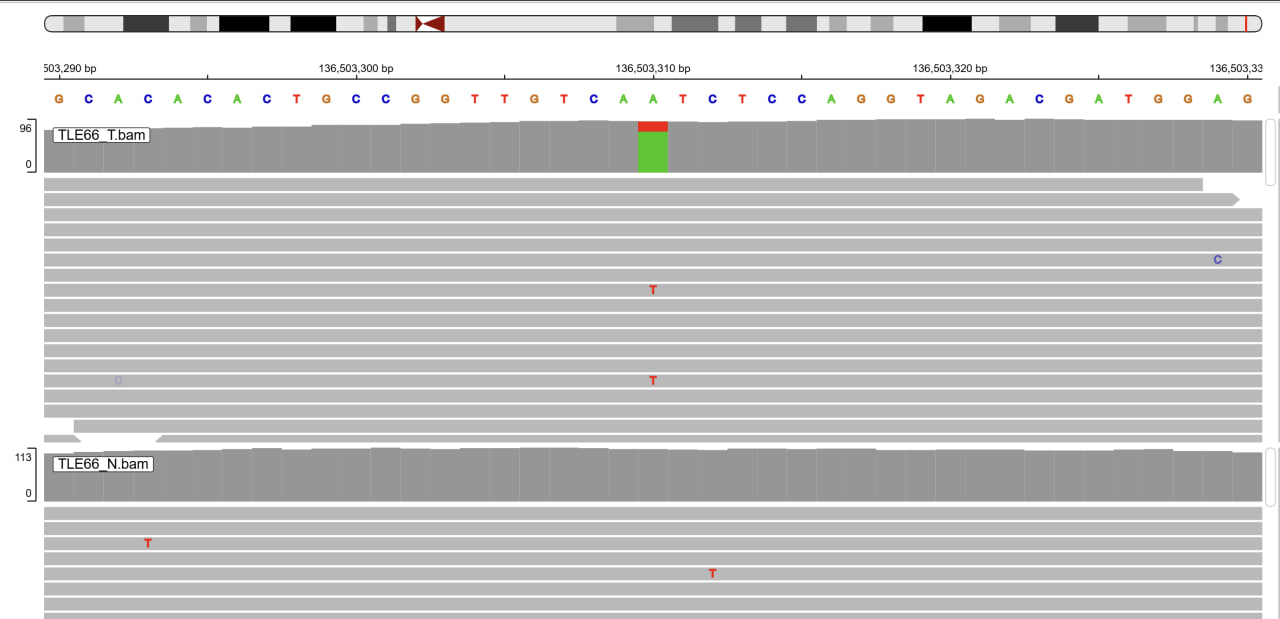

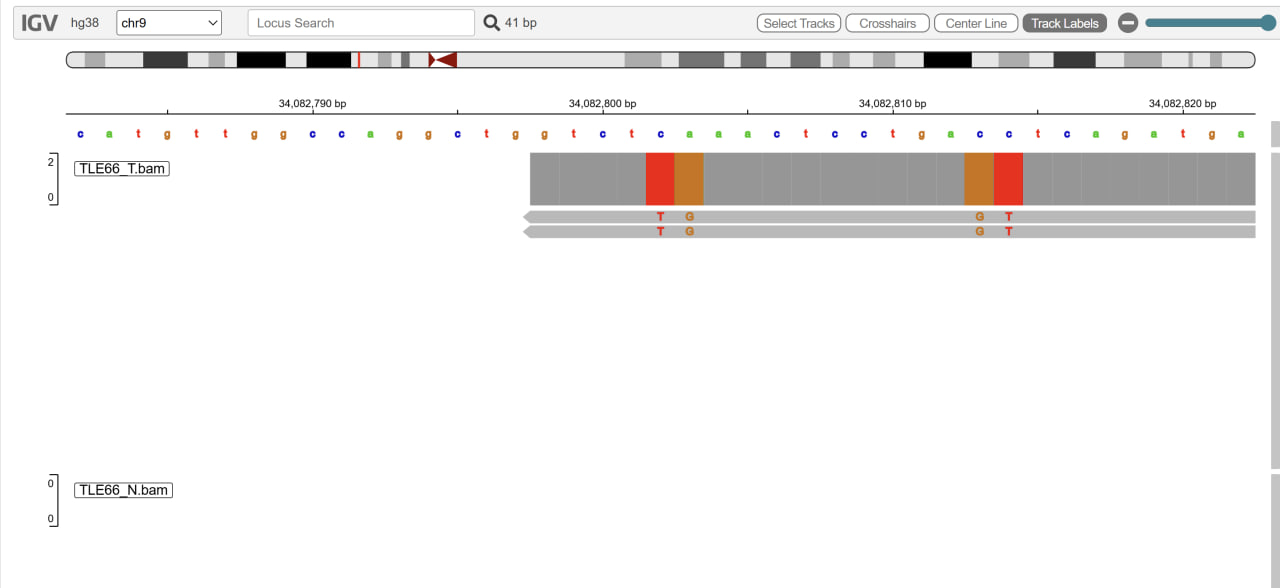

## Snp Annotation using SnpEff

In [ ]:
# get help using:
snpEff || true

In [ ]:
# sorry this is ugly - but to run snpEff - we need more memory
# I'm sure there is a more elegant way - but I could not find it..

SNPEFF_JAR="/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar"

java -Xmx3400m -jar ${SNPEFF_JAR} eff hg19 -dataDir /staging/leuven/stg_00079/teaching/snpeff_db \
        clean_snps.vcf > annotated_snps.vcf

In [ ]:
# confirm which java you're using now
which java
java -version

# force the course conda java (should be newer)
export PATH=/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin:$PATH
hash -r

which java
java -version

In [ ]:
/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/java -version

In [ ]:
SNPEFF_JAR="/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar"

/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/java -Xmx3400m -jar ${SNPEFF_JAR} eff hg19 \
  -dataDir /staging/leuven/stg_00079/teaching/snpeff_db \
  clean_snps.vcf > annotated_snps.vcf

<div style="background-color: khaki; padding: 10px;">

## snpEff Quality control

* Do you have annotations in the records? Show one HIGH impact one? 
* Can you think of other (simple) controls for a snpEff annotated vcf file?

</div>


In [ ]:
ls -lh annotated_snps.vcf
grep -m 1 -v '^#' annotated_snps.vcf

In [ ]:
grep 'HIGH' annotated_snps.vcf | head

1. Yes, the annotated VCF file contains SnpEff annotations in the ANN= field of the INFO column. Each variant includes predicted effects such as:
- intron_variant
- downstream_gene_variant
- frameshift_variant
- stop_gained
I searched for HIGH impact variants using: grep 'HIGH' annotated_snps.vcf | head
One example of a HIGH-impact variant is:
- Chromosome: chr9
- Position: 127912188
- Gene: PPP6C
- Effect: frameshift_variant
- Impact: HIGH
This variant causes a frameshift in a protein-coding transcript, which is considered a severe functional impact.
Other HIGH impact examples include:
- stop_gained (e.g., ABL1)
- splice_acceptor_variant (e.g., NCS1)
- frameshift_variant (e.g., SETX, AK8)
- This confirms that SnpEff annotation worked correctly.
2. Some simple quality control checks include confirming that the ANN field is present in the INFO column, which indicates that SnpEff successfully added annotations. It is also useful to verify that variants are assigned to different impact categories such as HIGH, MODERATE, LOW, and MODIFIER. Additionally, checking that gene names and transcript IDs appear in the annotations helps confirm that the variants were properly linked to genomic features. A few variants can also be inspected manually to see whether the predicted effects seem biologically reasonable. Finally, it is important to ensure that the VCF structure, including the header and column formatting, remains correct after the annotation step. Together, these checks help confirm that the SnpEff annotation process completed successfully.